In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns


In [11]:
df = pd.read_csv("../data/stud.csv")

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [13]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [14]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [15]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [20]:
print("Categories in 'gender' variable:", end=" ")
print(df["gender"].unique())

print("Categories in 'race/ethnicity' variable:", end=" ")
print(df["race_ethnicity"].unique())

print("Categories in 'parental level of education' variable:", end=" ")
print(df["parental_level_of_education"].unique())   

print("Categories in 'lunch variable:", end=" ")
print(df["lunch"].unique())

print("Categories in 'test preparation course' variable:", end=" ")
print(df["test_preparation_course"].unique())

Categories in 'gender' variable: <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in 'race/ethnicity' variable: <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in 'parental level of education' variable: <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in 'lunch variable: <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in 'test preparation course' variable: <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [21]:
numeric_features = [feature for feature in df.columns if df[feature].dtype != "O"]
categorical_features = [feature for feature in df.columns if df[feature].dtype == "O"]

print("We have {} numerical features: {}".format(len(numeric_features), numeric_features))
print("We have {} categorical features: {}".format(len(categorical_features), categorical_features))

We have 8 numerical features: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course', 'math_score', 'reading_score', 'writing_score']
We have 0 categorical features: []


In [22]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [23]:
df["Total_score"] = df["math_score"] + df["reading_score"] + df["writing_score"]
df["Average_score"] = df["Total_score"] / 3

In [24]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_score,Average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [27]:
reading_full = df[df["reading_score"]==100]["Average_score"].count()
writing_full = df[df["writing_score"]==100]["Average_score"].count()
math_full = df[df["math_score"]==100]["Average_score"].count()

print("Number of students with full marks in reading:", reading_full)
print("Number of students with full marks in writing:", writing_full)       
print("Number of students with full marks in math:", math_full)

Number of students with full marks in reading: 17
Number of students with full marks in writing: 14
Number of students with full marks in math: 7


In [28]:
reading_score_20 = df[df["reading_score"] <= 20]["Average_score"].count()
writing_score_20 = df[df["writing_score"] <= 20]["Average_score"].count()
math_score_20 = df[df["math_score"] <= 20]["Average_score"].count()

print("Number of students with less than or equal to 20 marks in reading:", reading_score_20)
print("Number of students with less than or equal to 20 marks in writing:", writing_score_20)
print("Number of students with less than or equal to 20 marks in math:", math_score_20) 

Number of students with less than or equal to 20 marks in reading: 1
Number of students with less than or equal to 20 marks in writing: 3
Number of students with less than or equal to 20 marks in math: 4


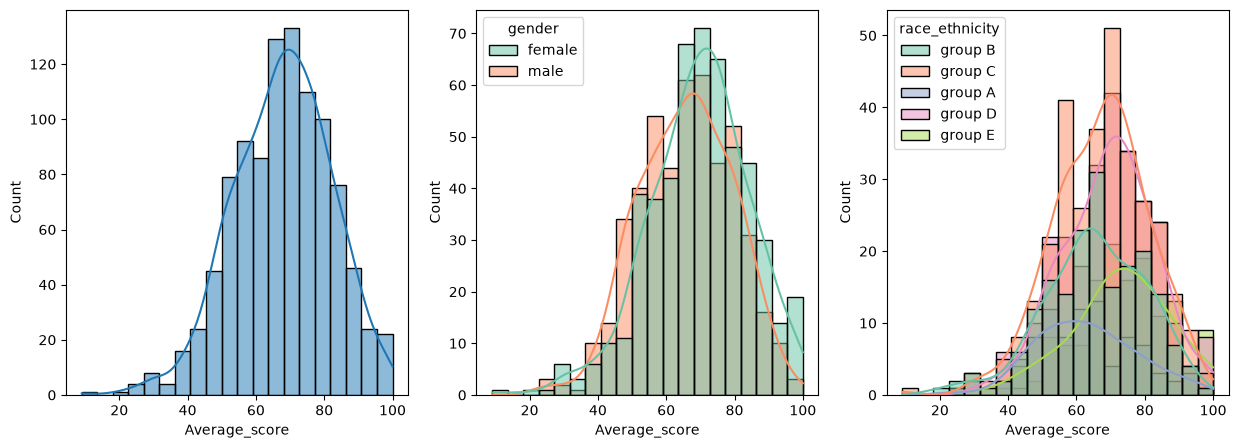

In [33]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
plt.subplot(131)
sns.histplot(data=df, x="Average_score", bins=20, kde=True)

plt.subplot(132)
sns.histplot(data=df, x="Average_score", hue="gender", palette="Set2", kde =True, bins=20)


plt.subplot(133)
sns.histplot(data=df, x="Average_score", hue="race_ethnicity", palette="Set2", kde =True, bins=20)  
plt.show()


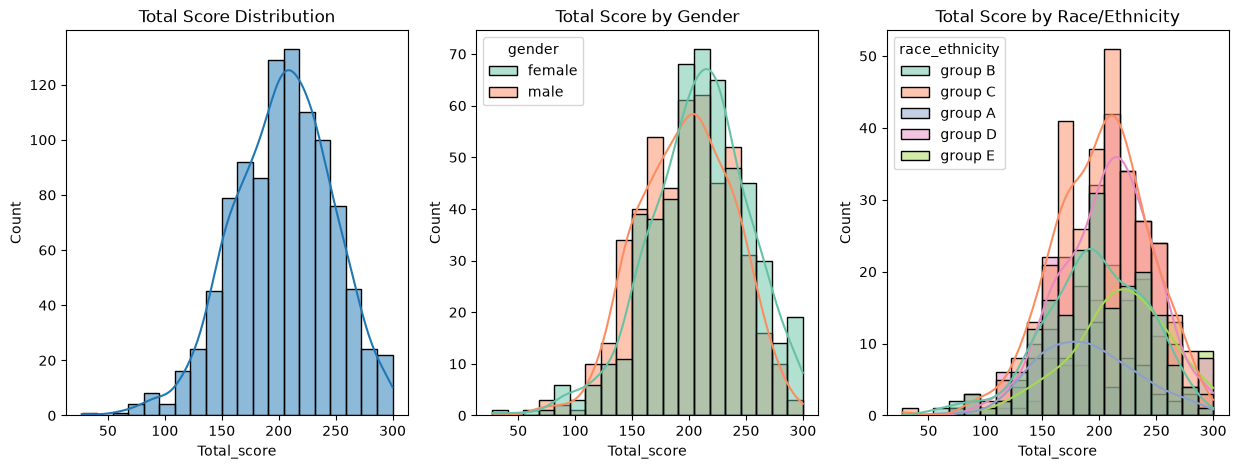

In [34]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
plt.subplot(131)
sns.histplot(data=df, x="Total_score", bins=20, kde=True)
plt.title("Total Score Distribution")

plt.subplot(132)
sns.histplot(data=df, x="Total_score", hue="gender", palette="Set2", kde =True, bins=20)
plt.title("Total Score by Gender")

plt.subplot(133)
sns.histplot(data=df, x="Total_score", hue="race_ethnicity", palette="Set2", kde =True, bins=20)  
plt.title("Total Score by Race/Ethnicity")
plt.show()


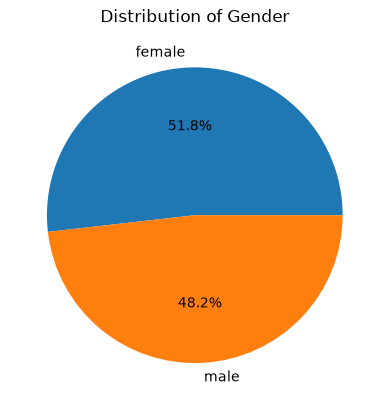

In [36]:
plt.pie(df["gender"].value_counts(), labels=df["gender"].value_counts().index, autopct="%1.1f%%")
plt.title("Distribution of Gender")
plt.show()

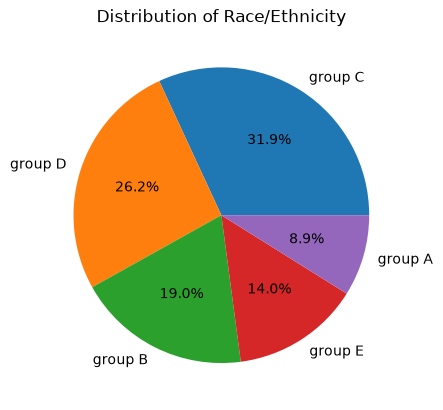

In [37]:
plt.pie(df["race_ethnicity"].value_counts(), labels=df["race_ethnicity"].value_counts().index, autopct="%1.1f%%")
plt.title("Distribution of Race/Ethnicity")
plt.show()

In [38]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_score,Average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


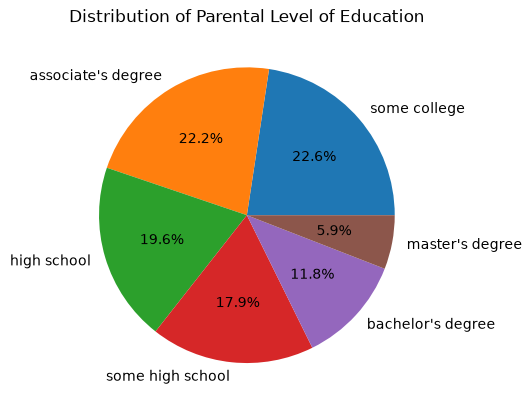

In [40]:
plt.pie(df["parental_level_of_education"].value_counts(), labels = df["parental_level_of_education"].value_counts().index, autopct="%1.1f%%")
plt.title("Distribution of Parental Level of Education")
plt.show()